# Projekt: Segmentacja Klientów Kart Kredytowych
**Cel analizy:** Głównym celem biznesowym projektu jest podział bazy klientów banku posiadających karty kredytowe na klastry w oparciu o ich zachowania finansowe. 
Wyodrębnienie profili klientów pozwoli na lepsze dopasowanie kampanii marketingowych oraz skuteczniejsze zarządzanie ryzykiem kredytowym. Do realizacji zadania wykorzystane zostały techniki uczenia nienadzorowanego.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import umap
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
from scipy.stats import zscore
from scipy.spatial.distance import mahalanobis
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


dane = pd.read_csv("CC GENERAL.csv")

In [92]:
dane.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [93]:
dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [94]:
dane.MINIMUM_PAYMENTS = dane.MINIMUM_PAYMENTS.fillna(dane.MINIMUM_PAYMENTS.median())
dane.CREDIT_LIMIT = dane.CREDIT_LIMIT.fillna(dane.CREDIT_LIMIT.median())

In [95]:
dane = dane.drop(columns=('CUST_ID'))

## 1. Eksploracyjna Analiza Danych (EDA) i Czyszczenie
W pierwszej kolejności uzupełniono braki danych w kolumnach `MINIMUM_PAYMENTS` oraz `CREDIT_LIMIT` przy użyciu mediany, aby nie zaburzać rozkładów. Usunięto również kolumnę ID, która nie niesie żadnej wartości analitycznej.
Poniżej zaprezentowano rozkłady zmiennych oraz macierz korelacji, która pozwala zidentyfikować ewentualną współliniowość cech.

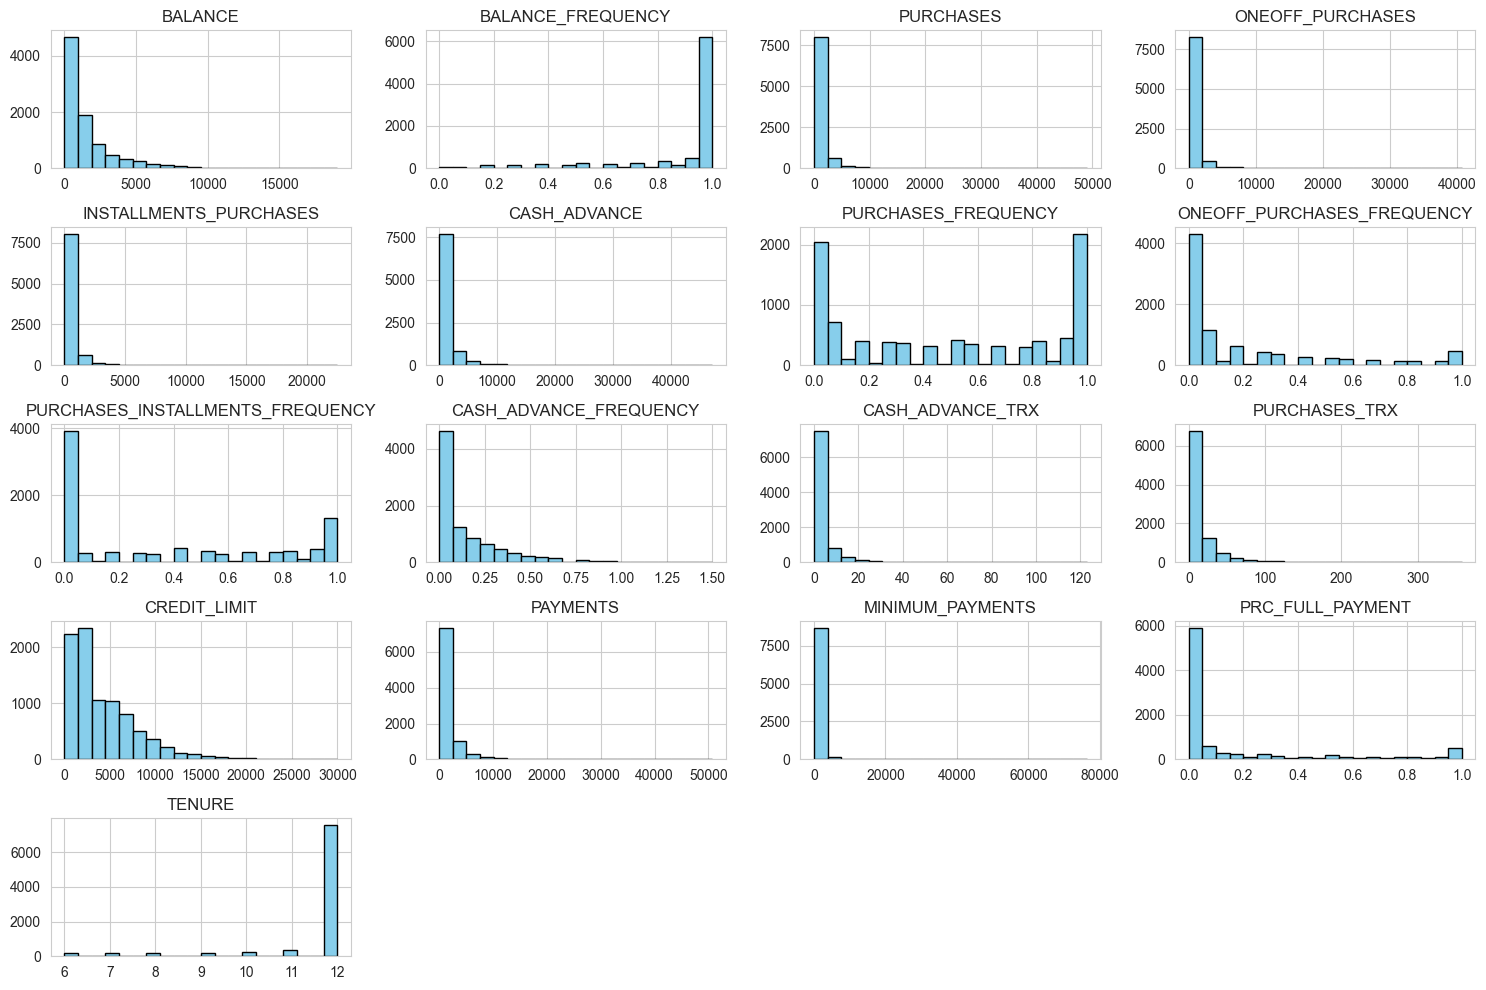

In [96]:
dane.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

In [97]:
dane.loc[dane['CASH_ADVANCE_FREQUENCY'] > 1, 'CASH_ADVANCE_FREQUENCY'] = 1

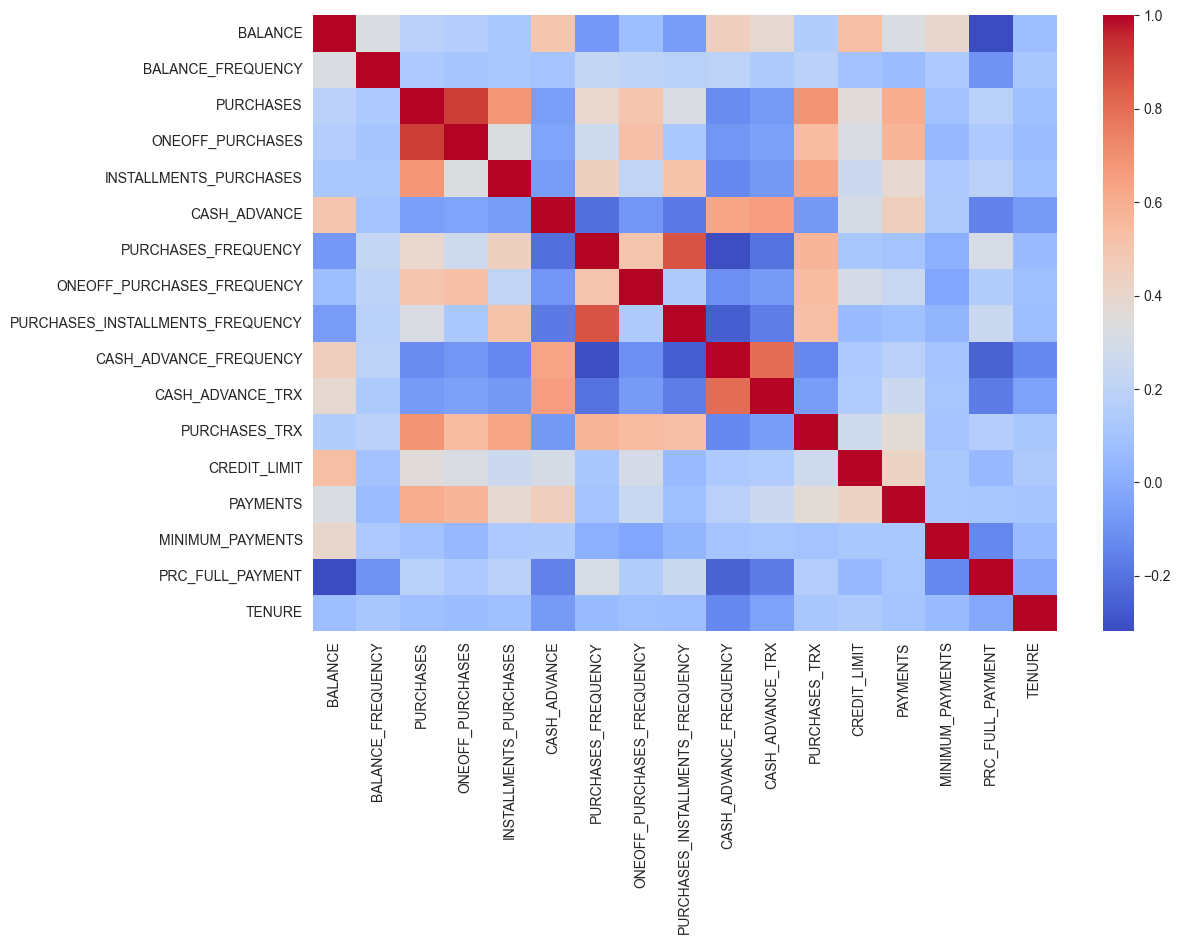

In [98]:
def color(value):
    if abs(value) <= 0.5:
        color = 'green'
    elif 0.5 < abs(value) <= 0.9:
        color = 'orange'
    elif abs(value) > 0.9:
        color = 'red'
    else:
        color = 'black'
    return 'color: {0}'.format(color)
    
corr = dane.corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(dane.corr(),cmap = 'coolwarm')
plt.show()

## 2. Analiza Wartości Odstających
Dane finansowe charakteryzują się wysoką skośnością i obecnością wartości odstających. Poniższe wykresy pudełkowe oraz tabela oparta na metodzie rozstępu międzykwartylowego obrazują skalę tego zjawiska.

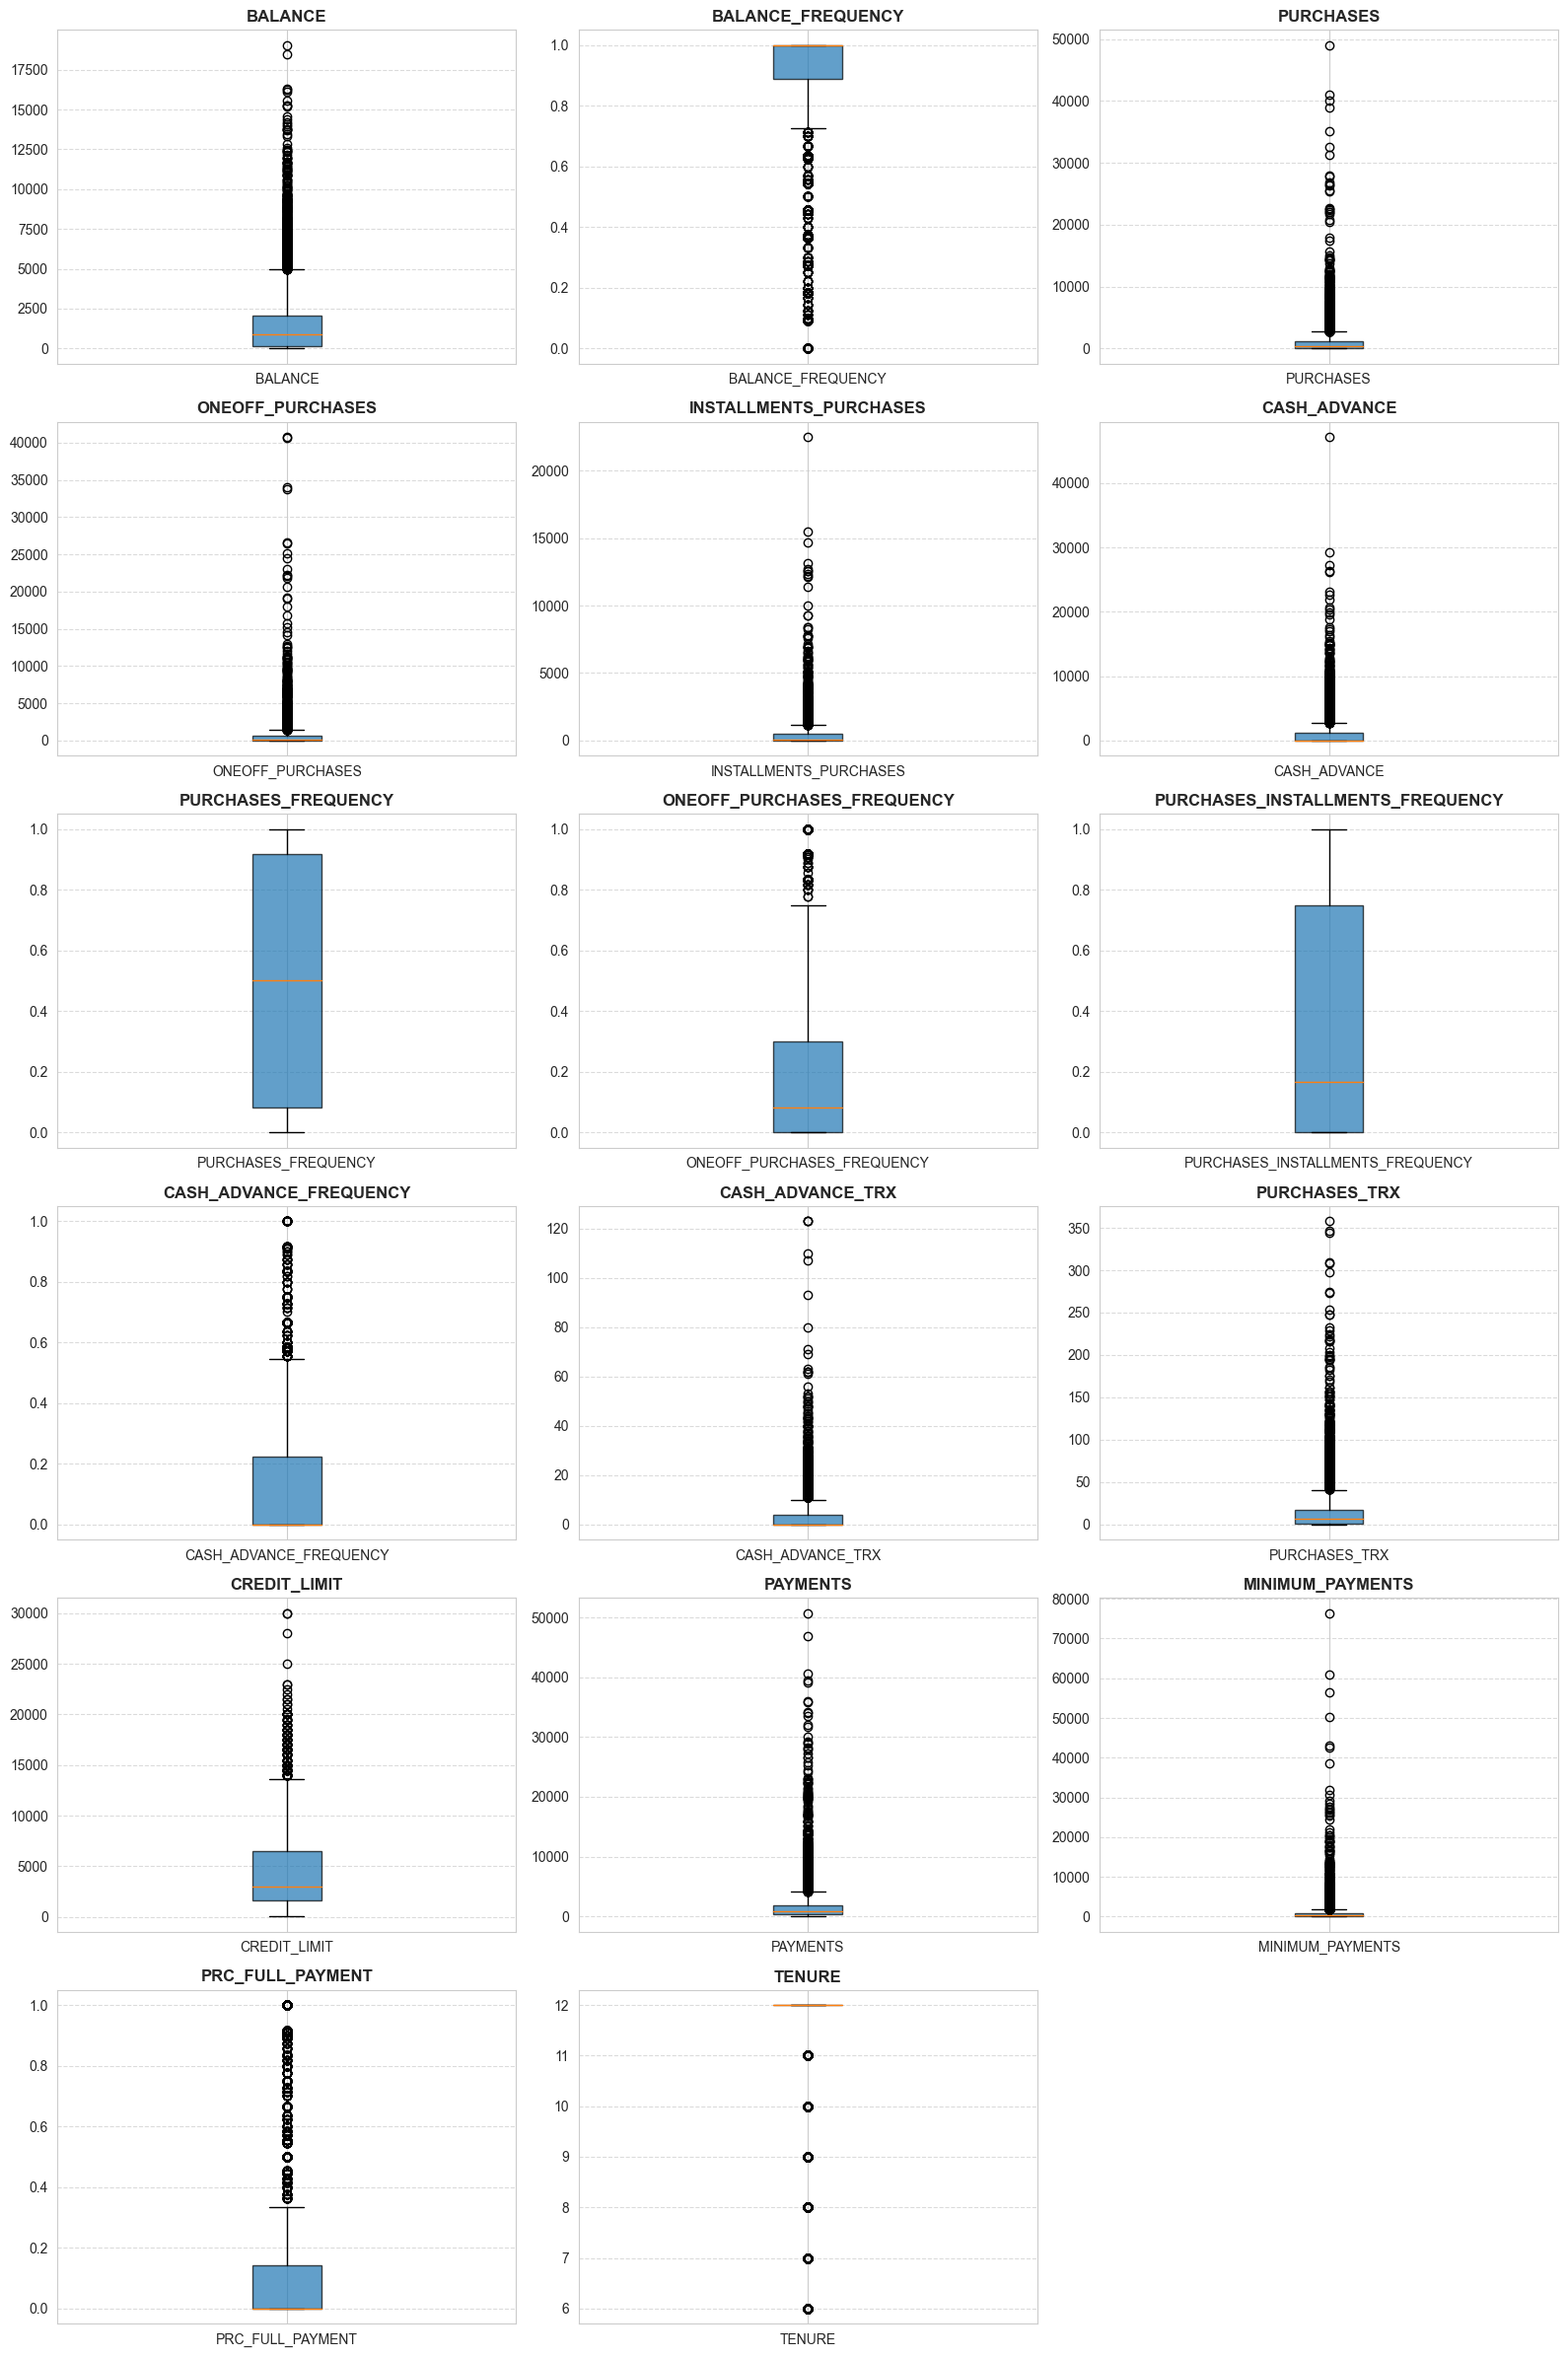

In [99]:
kolumny_numeryczne = dane.select_dtypes(include=['number']).columns
kolumny_ciagle = [col for col in kolumny_numeryczne if dane[col].nunique() > 2]
ile_wykresow = len(kolumny_ciagle)
kolumny_w_rzedzie = 3
rzedy = math.ceil(ile_wykresow / kolumny_w_rzedzie)
fig, axes = plt.subplots(nrows=rzedy, ncols=kolumny_w_rzedzie, figsize=(16, 4 * rzedy))
axes = axes.flatten() 

for i, col in enumerate(kolumny_ciagle):
    ax = axes[i]
    box = ax.boxplot(
        dane[col].dropna(), 
        patch_artist=True, 
        labels=[col]
    )    
    for patch in box['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

for j in range(ile_wykresow, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [100]:
def zlicz_outliery(df):
    """
    Funkcja zlicza wartości odstające metodą IQR dla zmiennych ciągłych w DataFrame.
    Zwraca posortowaną tabelę z wynikami.
    """
    kolumny_numeryczne = df.select_dtypes(include=['number']).columns
    kolumny_ciagle = [col for col in kolumny_numeryczne if df[col].nunique() > 2]
    
    wyniki = {}
    
    for col in kolumny_ciagle:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        dolna_granica = Q1 - 1.5 * IQR
        gorna_granica = Q3 + 1.5 * IQR
        
        outliery = df[(df[col] < dolna_granica) | (df[col] > gorna_granica)]
        wyniki[col] = len(outliery)
        
    wyniki_df = pd.DataFrame(list(wyniki.items()), columns=['Zmienna', 'Liczba_outlierów'])
    wyniki_df = wyniki_df.sort_values(by='Liczba_outlierów', ascending=False).reset_index(drop=True)
    
    wyniki_df['Procent_outlierów [%]'] = round((wyniki_df['Liczba_outlierów'] / len(df)) * 100, 2)
    
    return wyniki_df

tabela_outlierow = zlicz_outliery(dane)
display(tabela_outlierow)

,Zmienna,Liczba_outlierów,Procent_outlierów [%]
0,BALANCE_FREQUENCY,1493,16.68
1,PRC_FULL_PAYMENT,1474,16.47
2,TENURE,1366,15.26
3,CASH_ADVANCE,1030,11.51
4,ONEOFF_PURCHASES,1013,11.32
5,MINIMUM_PAYMENTS,909,10.16
6,INSTALLMENTS_PURCHASES,867,9.69
7,PAYMENTS,808,9.03
8,PURCHASES,808,9.03
9,CASH_ADVANCE_TRX,804,8.98


## 3. Transformacja i Skalowanie Danych
Algorytmy klasteryzacji opierają się na liczeniu fizycznych odległości między punktami. Pozostawienie danych w oryginalnych skalach spowodowałoby całkowite zdominowanie modelu przez duże liczby.

Jak widać na poniższym porównaniu na zmiennej `BALANCE`, skalowanie nie zmienia fizycznego "kształtu" rozkładu danych, a jedynie standaryzuje oś X. Do dalszych etapów modelowania wybrano **StandardScaler**, który wyśrodkowuje dane wokół zera.

In [101]:
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(dane), columns=dane.columns)

In [102]:
standard = StandardScaler()
df_std = pd.DataFrame(standard.fit_transform(dane), columns=dane.columns)

In [103]:
robust = RobustScaler()
df_robust = pd.DataFrame(robust.fit_transform(dane), columns=dane.columns)

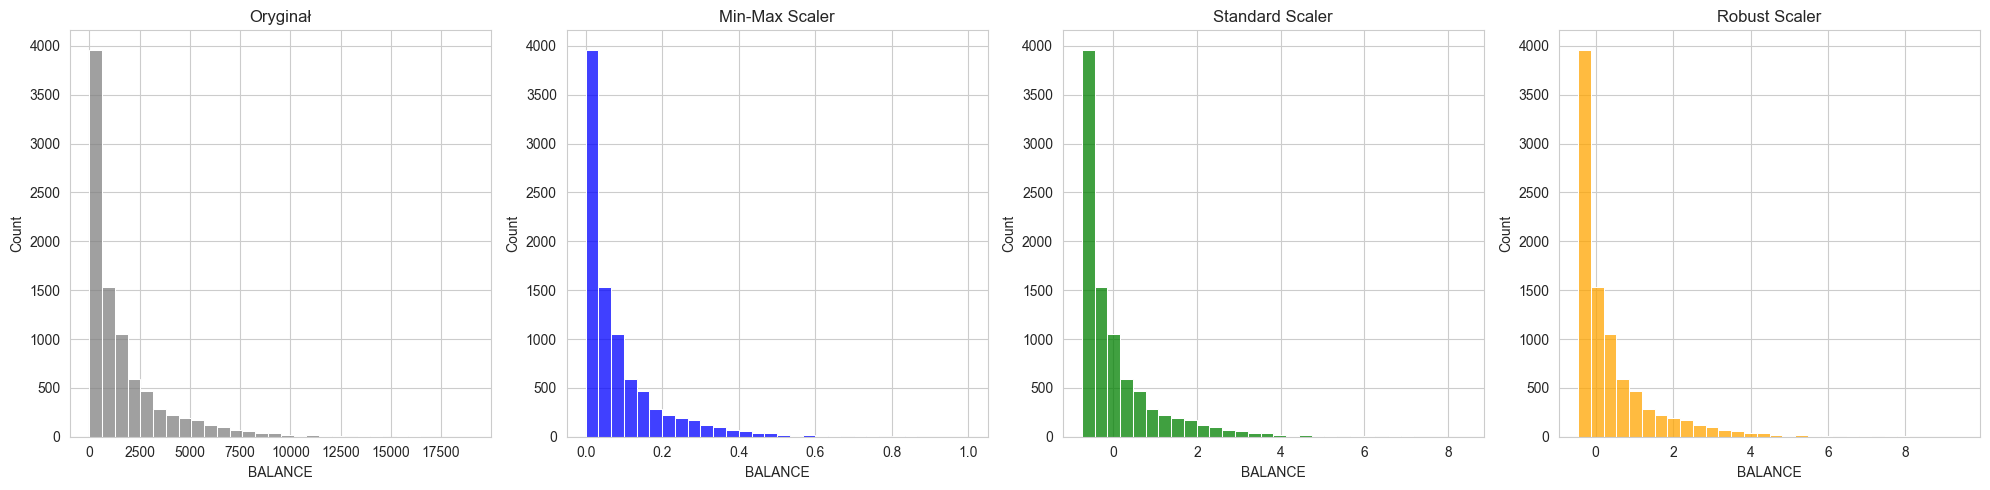

In [104]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(dane['BALANCE'], bins=30, ax=axes[0], color='gray')
axes[0].set_title('Oryginał')

sns.histplot(df_minmax['BALANCE'], bins=30, ax=axes[1], color='blue')
axes[1].set_title('Min-Max Scaler')

sns.histplot(df_std['BALANCE'], bins=30, ax=axes[2], color='green')
axes[2].set_title('Standard Scaler')

sns.histplot(df_robust['BALANCE'], bins=30, ax=axes[3], color='orange')
axes[3].set_title('Robust Scaler')

plt.tight_layout()
plt.show()

In [105]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
labels_kmeans = kmeans.fit_predict(df_std)

pd.Series(labels_kmeans).value_counts()

3    3974
2    3365
0    1202
1     409
dtype: int64

## 4. Modelowanie: Optymalizacja algorytmu K-Means
W celu znalezienia optymalnej liczby klastrów ($k$) dla algorytmu K-Means, zastosowano dwie metody ewaluacji:
1. **Metodę Łokcia (Elbow Method)** - poszukujemy momentu, w którym spadek wariancji wewnątrz klastrów zaczyna hamować.
2. **Miara Silhouette** - ocenia, jak dobrze punkty są dopasowane do własnego klastra w porównaniu z innymi klastrami. Poszukujemy globalnego maksimum na wykresie.

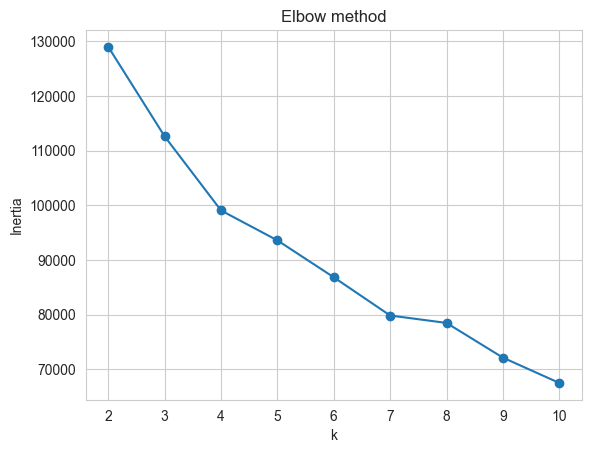

In [106]:
inertia = []
K = range(2,11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(df_std)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker = 'o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

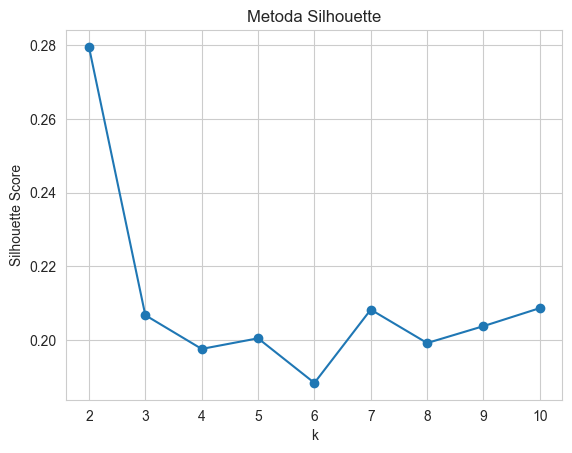

In [107]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(df_std)
    score = silhouette_score(df_std, labels)
    silhouette_scores.append(score)

plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Metoda Silhouette")
plt.show()

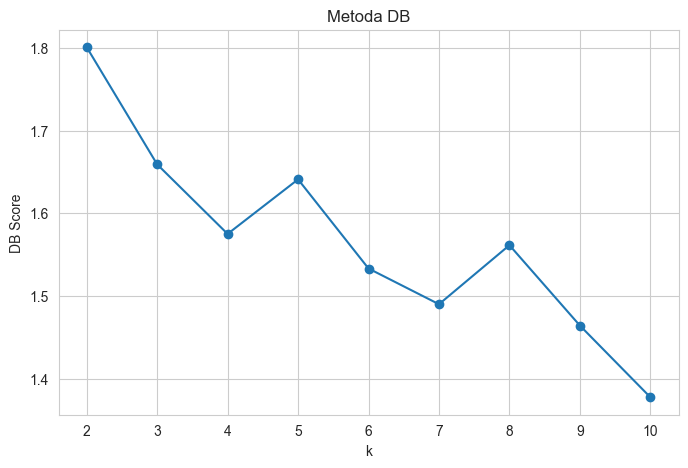

In [108]:
db_scores = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(df_std)
    score = davies_bouldin_score(df_std, labels)
    db_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, db_scores, marker='o')
plt.xlabel("k")
plt.ylabel("DB Score")
plt.title("Metoda DB")
plt.show()

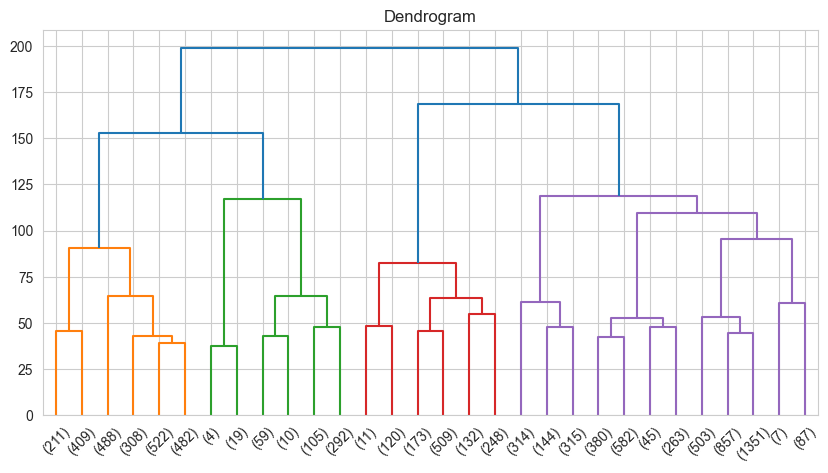

In [109]:
linked = linkage(df_std, method="ward")
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp',p=30)
plt.title("Dendrogram")
plt.show()

In [110]:
hier = AgglomerativeClustering(4, linkage='ward')
labels_hier = hier.fit_predict(df_std)

pd.Series(labels_hier).value_counts()

0    4848
3    2420
2    1193
1     489
dtype: int64

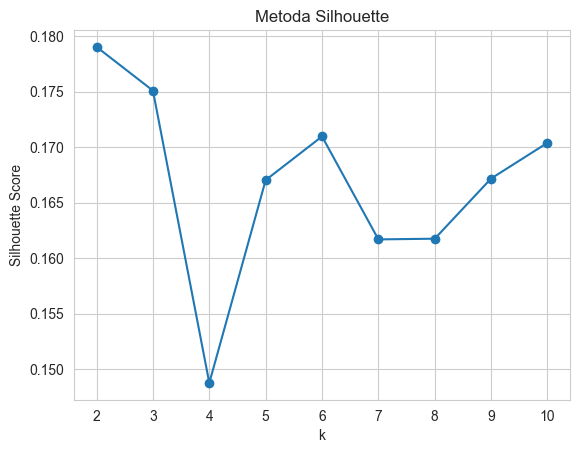

In [111]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    hier = AgglomerativeClustering(k, linkage='ward')
    labels = hier.fit_predict(df_std)
    score = silhouette_score(df_std, labels)
    silhouette_scores.append(score)

plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Metoda Silhouette")
plt.show()

In [112]:
dbscan = DBSCAN(eps=1,min_samples=10)
labels_db = dbscan.fit_predict(df_std)

pd.Series(labels_db).value_counts()

 0    5272
-1    3634
 1      34
 2      10
dtype: int64

## 5. Benchmark Modeli (K-Means vs. Hierarchiczna vs. DBSCAN)
Aby upewnić się, że K-Means jest najlepszym wyborem, zestawiamy jego wyniki z klasteryzacją Hierarchiczną oraz gęstościowym algorytmem DBSCAN. Wykorzystujemy do tego wskaźniki: **Silhouette Score** oraz **Davies-Bouldin Score**.

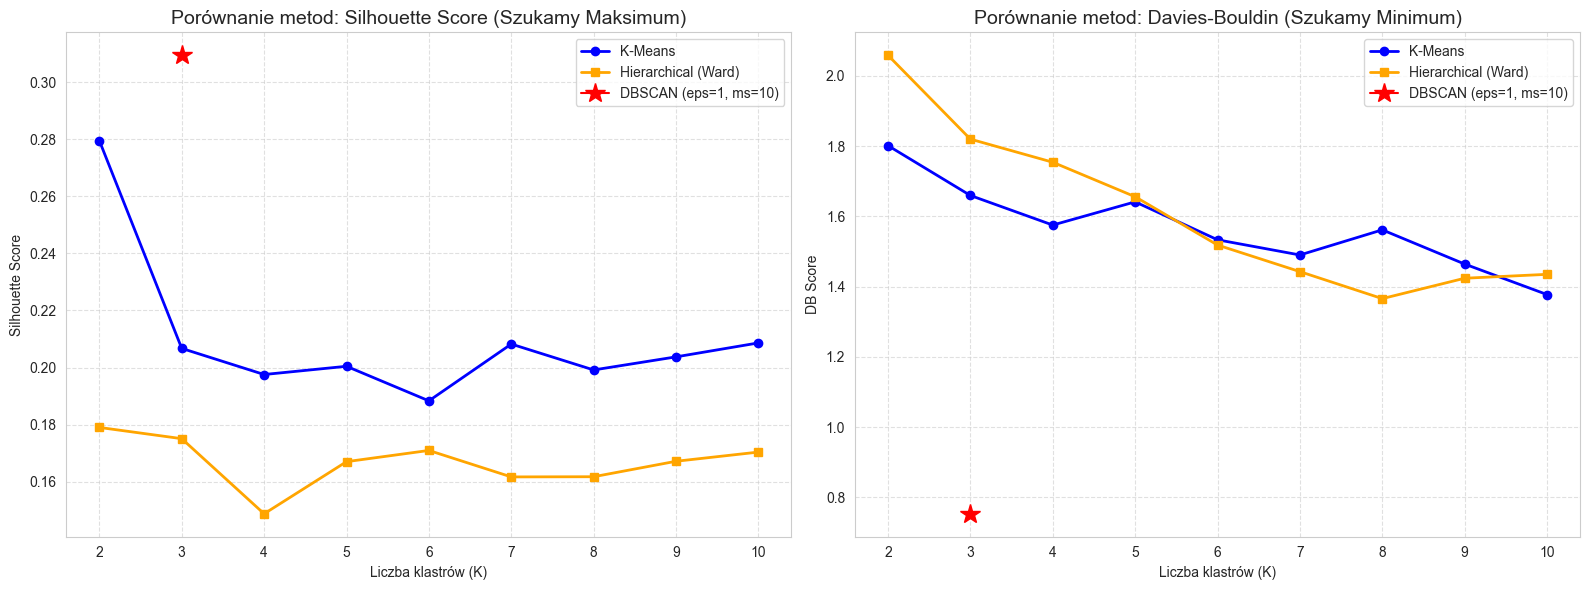

In [113]:
K = range(2, 11)

km_sil, km_db = [], []
hier_sil, hier_db = [], []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km_labels = km.fit_predict(df_std)
    km_sil.append(silhouette_score(df_std, km_labels))
    km_db.append(davies_bouldin_score(df_std, km_labels))
    
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hier_labels = hier.fit_predict(df_std)
    hier_sil.append(silhouette_score(df_std, hier_labels))
    hier_db.append(davies_bouldin_score(df_std, hier_labels))

dbscan = DBSCAN(eps=1, min_samples=10)
labels_db = dbscan.fit_predict(df_std)

mask = labels_db != -1
if len(set(labels_db[mask])) > 1:
    dbscan_sil = silhouette_score(df_std[mask], labels_db[mask])
    dbscan_db = davies_bouldin_score(df_std[mask], labels_db[mask])
    liczba_klastrow_dbscan = len(set(labels_db[mask]))
else:
    dbscan_sil, dbscan_db, liczba_klastrow_dbscan = None, None, None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(K, km_sil, marker='o', label='K-Means', color='blue', linewidth=2)
ax1.plot(K, hier_sil, marker='s', label='Hierarchical (Ward)', color='orange', linewidth=2)

if dbscan_sil is not None:
    ax1.plot(liczba_klastrow_dbscan, dbscan_sil, marker='*', markersize=15, 
             color='red', label=f'DBSCAN (eps=1, ms=10)')

ax1.set_title('Porównanie metod: Silhouette Score (Szukamy Maksimum)', fontsize=14)
ax1.set_xlabel('Liczba klastrów (K)')
ax1.set_ylabel('Silhouette Score')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(K, km_db, marker='o', label='K-Means', color='blue', linewidth=2)
ax2.plot(K, hier_db, marker='s', label='Hierarchical (Ward)', color='orange', linewidth=2)

if dbscan_db is not None:
    ax2.plot(liczba_klastrow_dbscan, dbscan_db, marker='*', markersize=15, 
             color='red', label=f'DBSCAN (eps=1, ms=10)')

ax2.set_title('Porównanie metod: Davies-Bouldin (Szukamy Minimum)', fontsize=14)
ax2.set_xlabel('Liczba klastrów (K)')
ax2.set_ylabel('DB Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Redukcja Wymiarowości i Wizualizacja (model: K-Means dla k=4)
Ponieważ nasz zbiór ma kilkanaście wymiarów, niemożliwe jest wyrysowanie go na standardowym płaskim wykresie. Aby na własne oczy zweryfikować jakość podziału na 4 klastry wygenerowanego przez K-Means, zastosowano potężne techniki redukcji wymiarowości: **PCA, t-SNE oraz UMAP**.
Pozwalają one "zgnieść" 17 zmiennych do zaledwie 2 wymiarów, zachowując przy tym relacje i odległości między klientami.

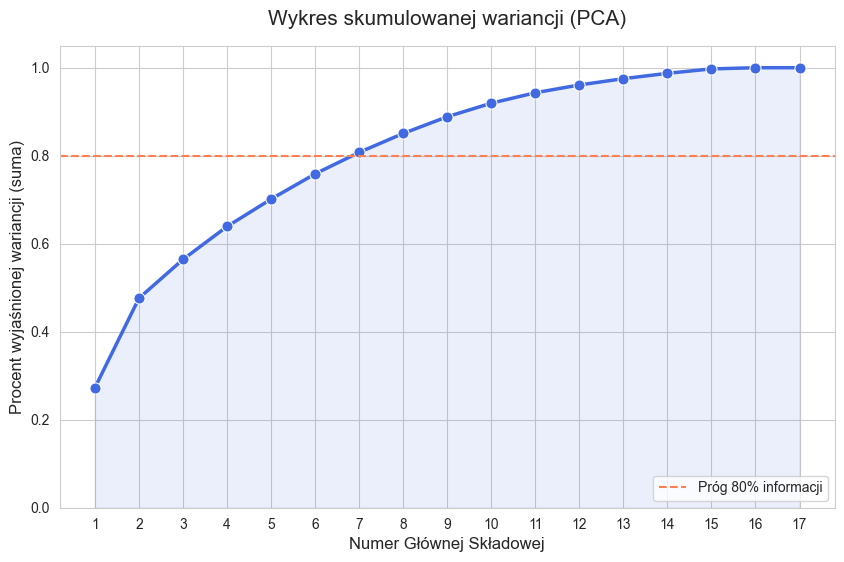

In [114]:
pca_full = PCA()
pca_full.fit(df_std)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
comp_names = [f"PC{i+1}" for i in range(len(cum_var))]

df_viz = pd.DataFrame({
    'Liczba komponentów': range(1, len(cum_var) + 1),
    'Skumulowana Wariancja': cum_var,
    'Komponent': comp_names
})

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.lineplot(data=df_viz, x='Liczba komponentów', y='Skumulowana Wariancja', 
             marker='o', markersize=8, color='royalblue', linewidth=2.5)
plt.fill_between(df_viz['Liczba komponentów'], df_viz['Skumulowana Wariancja'], alpha=0.1, color='royalblue')
plt.axhline(y=0.8, color='coral', linestyle='--', label='Próg 80% informacji')
plt.title('Wykres skumulowanej wariancji (PCA)', fontsize=15, pad=15)
plt.xlabel('Numer Głównej Składowej', fontsize=12)
plt.ylabel('Procent wyjaśnionej wariancji (suma)', fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(df_viz['Liczba komponentów'])
plt.legend(loc='lower right')
plt.show()

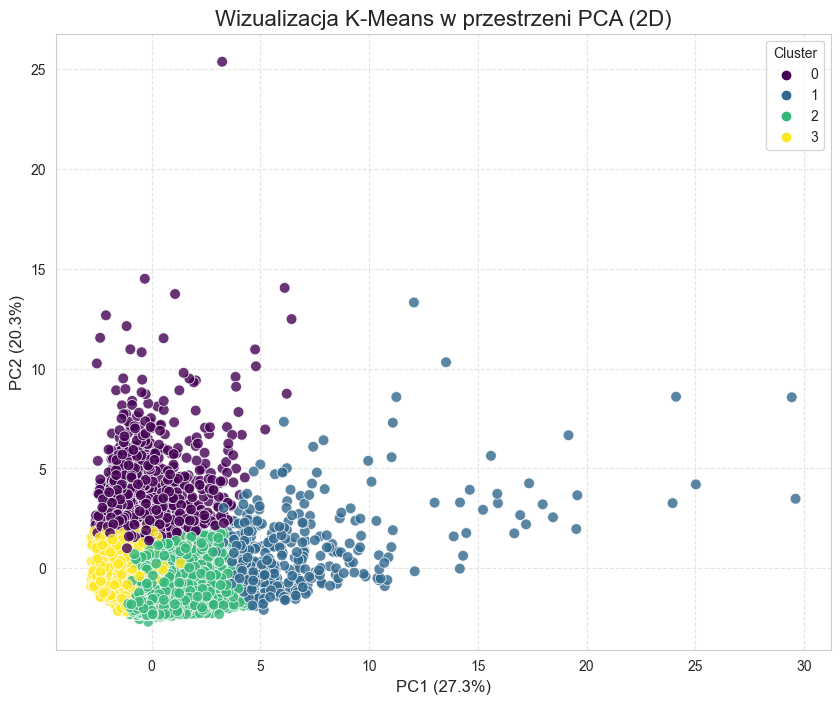

In [115]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_std)

df_pca_kmeans = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca_kmeans['Cluster'] = labels_kmeans

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca_kmeans, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60, alpha=0.8)
plt.title('Wizualizacja K-Means w przestrzeni PCA (2D)', fontsize=16)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

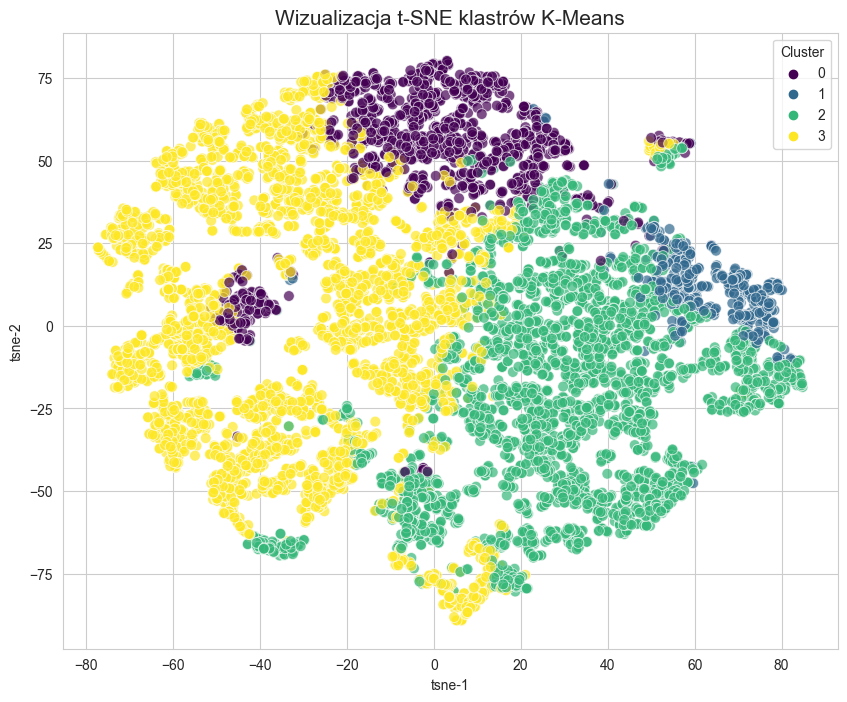

In [116]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate=200)
X_tsne = tsne.fit_transform(df_std)

df_tsne = pd.DataFrame(X_tsne, columns=['tsne-1', 'tsne-2'])
df_tsne['Cluster'] = labels_kmeans

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_tsne, x='tsne-1', y='tsne-2', hue='Cluster', palette='viridis', legend='full', alpha=0.7, s=60)
plt.title('Wizualizacja t-SNE klastrów K-Means', fontsize=15)
plt.show()

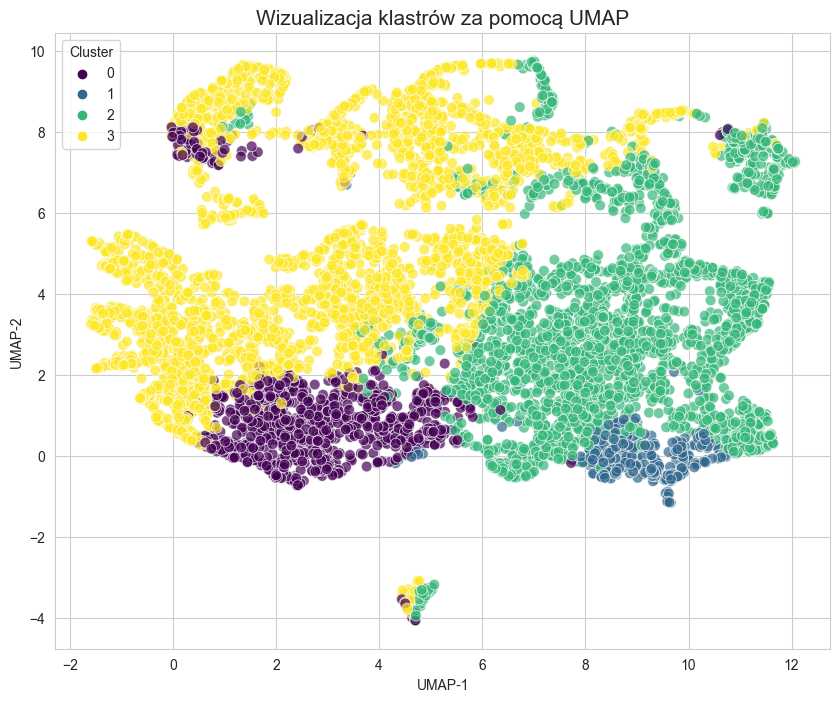

In [117]:
import warnings
warnings.filterwarnings('ignore')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(df_std)

df_umap = pd.DataFrame(X_umap, columns=['UMAP-1', 'UMAP-2'])
df_umap['Cluster'] = labels_kmeans 

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap, x='UMAP-1', y='UMAP-2', hue='Cluster', palette='viridis', s=60, alpha=0.7)
plt.title('Wizualizacja klastrów za pomocą UMAP', fontsize=15)
plt.show()

## 7. Podsumowanie: Profilowanie Biznesowe Segmentów
W ostatnim kroku przypisujemy wygenerowane etykiety klastrów z powrotem do **oryginalnych, nieskalowanych danych**. Następnie analizujemy kluczowe zmienne za pomocą wykresów pudełkowych, aby odpowiedzieć na pytanie: *Kim w rzeczywistości są klienci w poszczególnych klastrach?*

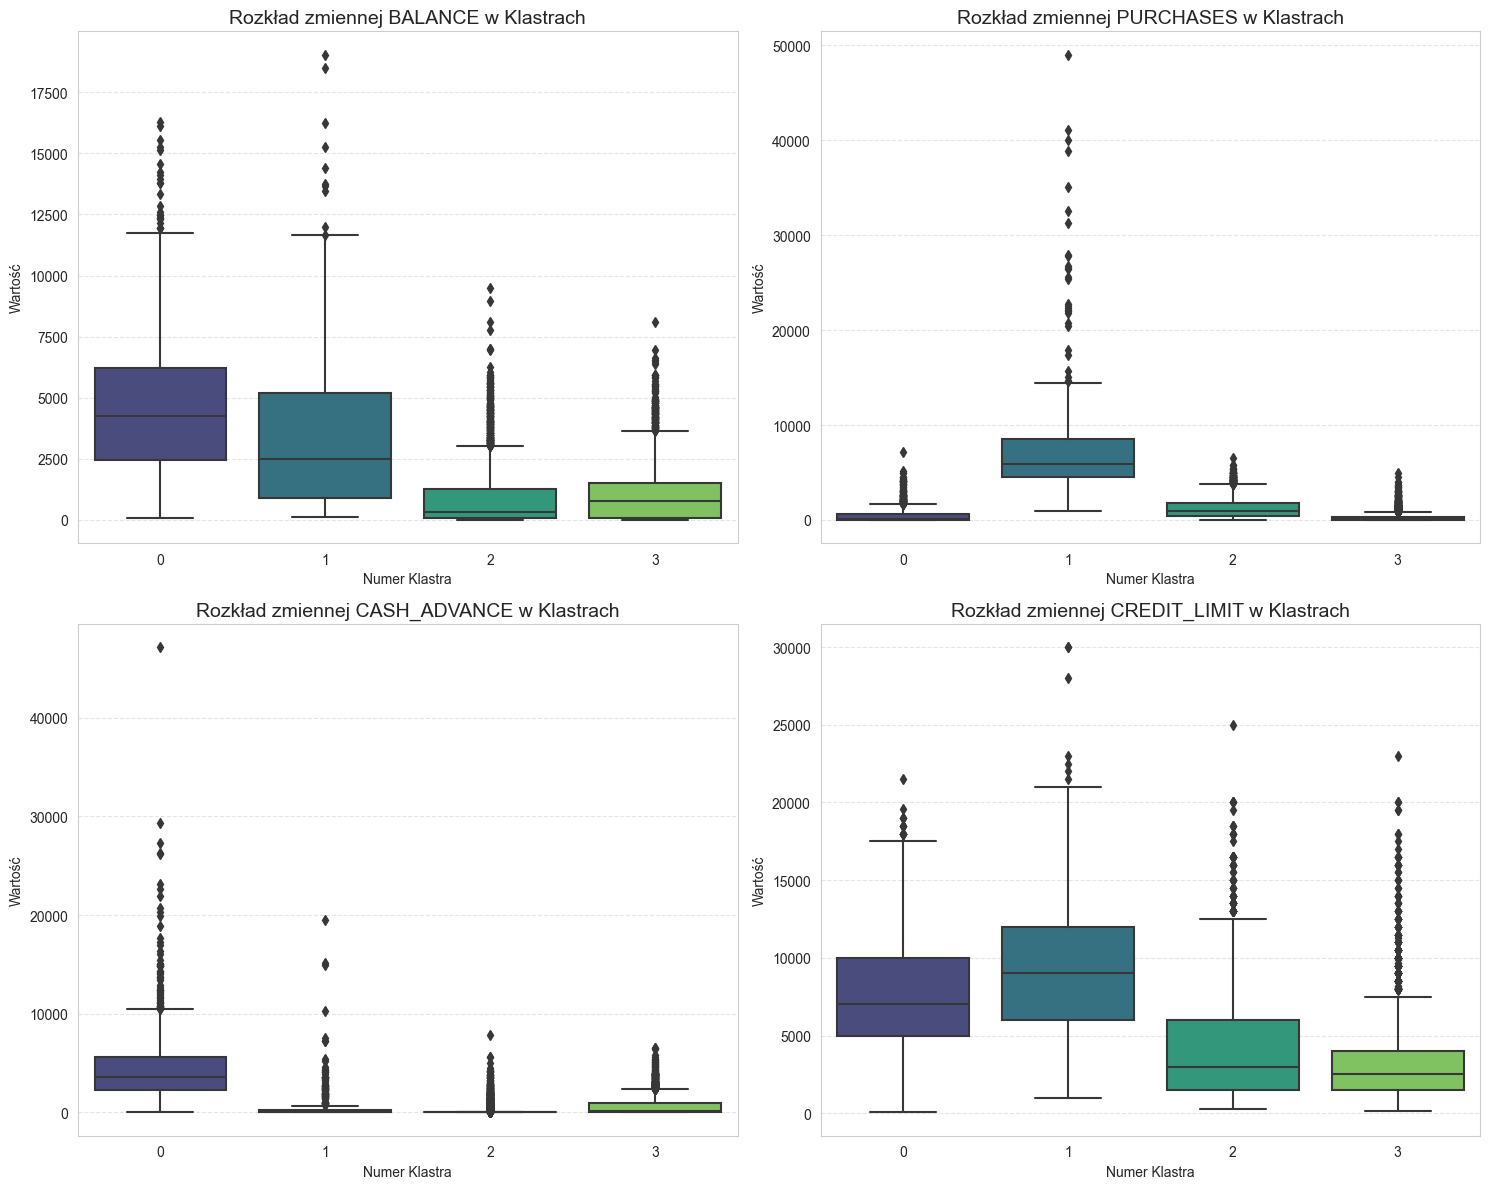

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT
Cluster,,,,
0,4590.76,501.61,4511.60,7532.41
1,3551.15,7681.62,653.64,9696.94
2,894.11,1236.00,209.18,4213.13
3,1012.29,270.47,595.55,3277.97


In [118]:

dane['Cluster'] = labels_kmeans

kluczowe_cechy = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(kluczowe_cechy):
    sns.boxplot(x='Cluster', y=feature, data=dane, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Rozkład zmiennej {feature} w Klastrach', fontsize=14)
    axes[i].set_xlabel('Numer Klastra')
    axes[i].set_ylabel('Wartość')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(round(dane.groupby('Cluster')[kluczowe_cechy].mean(), 2))